#### Importing required libraries

In [1]:
import matplotlib.pyplot as plt 
import mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
import seaborn as sns
import pandas as pd
import matplotlib.pylab as plt
import warnings
warnings.filterwarnings("ignore")
import numpy as np

#### Loading dataset statistics to get the final time cut 
* **The initial  time cut will be 10 minutes after the first post publication**
*  **The final time cut will be equal to 6 hours after the publication of last post**

In [2]:
df_posts_by_tm = pd.read_csv('ferguson_posts_by_time_cut.csv')

In [3]:
df_posts_by_tm['new_posts_cum_sum'] = df_posts_by_tm.new_posts.cumsum()

In [4]:
max_time_cut = int(df_posts_by_tm[df_posts_by_tm.new_posts_cum_sum==int(df_posts_by_tm.new_posts_cum_sum.max())]\
                   .time_cut.min())+(60*6)

In [5]:
max_time_cut

9083

#### HAN model

In [6]:
experiment = mlflow.get_experiment_by_name('HAN 2025-11-03 Ferguson')
print(experiment.name)

if experiment is not None:
    experiment_id = experiment.experiment_id

    # Retrieve all runs in the experiment as a DataFrame
    df_han = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
    
    # Show the DataFrame
    #print(df)
else:
    print(f"Experiment '{experiment_name}' not found.")
    
df_han = df_han[df_han['metrics.time_cut']<=max_time_cut]

HAN 2025-11-03 Ferguson


In [7]:
df_han.shape

(303, 19)

In [8]:
df_han['metrics.curr_f1'] = 2 * (
    df_han['metrics.curr_precision'] * df_han['metrics.curr_recall']
) / (
    df_han['metrics.curr_precision'] + df_han['metrics.curr_recall']
)

df_han['metrics.final_f1'] = 2 * (
    df_han['metrics.final_precision'] * df_han['metrics.final_recall']
) / (
    df_han['metrics.final_precision'] + df_han['metrics.final_recall']
)



#### GAT model

In [9]:
experiment = mlflow.get_experiment_by_name('GAT 2025-11-03 Ferguson')
print(experiment.name)

if experiment is not None:
    experiment_id = experiment.experiment_id

    # Retrieve all runs in the experiment as a DataFrame
    df_gat = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='metrics.time_cut')
    
    # Show the DataFrame
    #print(df)
else:
    print(f"Experiment '{experiment_name}' not found.")
df_gat = df_gat[df_gat['metrics.time_cut']<=max_time_cut]

GAT 2025-11-03 Ferguson


In [10]:
df_gat['metrics.curr_f1'] = 2 * (
    df_gat['metrics.curr_precision'] * df_gat['metrics.curr_recall']
) / (
    df_gat['metrics.curr_precision'] + df_gat['metrics.curr_recall']
)

df_gat['metrics.final_f1'] = 2 * (
    df_gat['metrics.final_precision'] * df_gat['metrics.final_recall']
) / (
    df_gat['metrics.final_precision'] + df_gat['metrics.final_recall']
)



In [11]:
df_gat.shape

(303, 21)

#### LSTM model

In [12]:
experiment = mlflow.get_experiment_by_name('LSTM 2025-11-04 Ferguson')
print(experiment.name)

if experiment is not None:
    experiment_id = experiment.experiment_id

    # Retrieve all runs in the experiment as a DataFrame
    df_lstm = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='metrics.test_recall')
    
    # Show the DataFrame
    #print(df)
else:
    print(f"Experiment '{experiment_name}' not found.")
df_lstm =df_lstm[df_lstm['metrics.time_cut']<=max_time_cut]

LSTM 2025-11-04 Ferguson


In [13]:

df_lstm.rename(columns={'metrics.test_precision':'metrics.final_precision',
                        'metrics.test_recall':'metrics.final_recall',
                        'metrics.test_auc':'metrics.final_auc'},inplace=True)

In [14]:
df_lstm['metrics.curr_f1'] = 2 * (
    df_lstm['metrics.curr_precision'] * df_lstm['metrics.curr_recall']
) / (
    df_lstm['metrics.curr_precision'] + df_lstm['metrics.curr_recall']
)

df_lstm['metrics.final_f1'] = 2 * (
    df_lstm['metrics.final_precision'] * df_lstm['metrics.final_recall']
) / (
    df_lstm['metrics.final_precision'] + df_lstm['metrics.final_recall']
)



In [15]:
df_lstm['metrics.time_cut'] = df_gat.iloc[:-1,]['metrics.time_cut']

In [16]:
df_lstm['metrics.new_posts'] = df_gat.iloc[:-1,]['metrics.new_posts']

In [17]:
df_lstm.shape

(302, 25)

#### Light GBM model

In [18]:
experiment = mlflow.get_experiment_by_name('LGBM 2025-11-03 Ferguson')
print(experiment.name)

if experiment is not None:
    experiment_id = experiment.experiment_id

    # Retrieve all runs in the experiment as a DataFrame
    df_lgb = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
    
    # Show the DataFrame
    #print(df)
else:
    print(f"Experiment '{experiment_name}' not found.")
df_lgb = df_lgb[df_lgb['metrics.time_cut']<=max_time_cut]

LGBM 2025-11-03 Ferguson


In [19]:
df_lgb['metrics.curr_f1'] = 2 * (
    df_lgb['metrics.curr_precision'] * df_lgb['metrics.curr_recall']
) / (
    df_lgb['metrics.curr_precision'] + df_lgb['metrics.curr_recall']
)

df_lgb['metrics.final_f1'] = 2 * (
    df_lgb['metrics.final_precision'] * df_lgb['metrics.final_recall']
) / (
    df_lgb['metrics.final_precision'] + df_lgb['metrics.final_recall']
)



In [20]:
df_lgb.shape

(302, 27)

#### Random Forest model

In [21]:
experiment = mlflow.get_experiment_by_name('Random Forest 2025-11-03 Ferguson')
print(experiment.name)

if experiment is not None:
    experiment_id = experiment.experiment_id

    # Retrieve all runs in the experiment as a DataFrame
    df_rf = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
    
    # Show the DataFrame
    #print(df)
else:
    print(f"Experiment '{experiment_name}' not found.")
df_rf = df_rf[df_rf['metrics.time_cut']<=max_time_cut]

Random Forest 2025-11-03 Ferguson


In [22]:
df_rf['metrics.curr_f1'] = 2 * (
    df_rf['metrics.curr_precision'] * df_rf['metrics.curr_recall']
) / (
    df_rf['metrics.curr_precision'] + df_rf['metrics.curr_recall']
)

df_rf['metrics.final_f1'] = 2 * (
    df_rf['metrics.final_precision'] * df_rf['metrics.final_recall']
) / (
    df_rf['metrics.final_precision'] + df_rf['metrics.final_recall']
)



In [23]:
df_rf.shape

(302, 27)

#### Creating Hours column

In [24]:
df_han['time_cut_hours'] = round(df_han['metrics.time_cut']/60,2)
df_gat['time_cut_hours'] = round(df_gat['metrics.time_cut']/60,2)
df_lgb['time_cut_hours'] = round(df_lgb['metrics.time_cut']/60,2)
df_rf['time_cut_hours'] = round(df_rf['metrics.time_cut']/60,2)
df_lstm['time_cut_hours'] = round(df_lstm['metrics.time_cut']/60,2)

#### Creating a single dataframe with all experiments

In [25]:

df_han =df_han.dropna(subset='metrics.time_cut')[['time_cut_hours','metrics.final_recall','metrics.final_auc','metrics.final_precision',\
                 'metrics.final_acc','metrics.curr_precision','metrics.curr_recall','metrics.curr_acc','metrics.new_posts',\
                'metrics.final_f1','metrics.curr_f1','metrics.time_cut']]

df_gat =df_gat.dropna(subset='metrics.time_cut')[['time_cut_hours','metrics.final_recall','metrics.final_auc','metrics.final_precision',\
                 'metrics.final_acc','metrics.curr_precision','metrics.curr_recall','metrics.curr_acc','metrics.new_posts','metrics.time_cut',\
                  'metrics.final_f1','metrics.curr_f1']]


df_lgb =df_lgb.dropna(subset='metrics.time_cut')[['time_cut_hours','metrics.final_recall','metrics.final_auc','metrics.final_precision',\
                 'metrics.final_acc','metrics.curr_precision','metrics.curr_recall','metrics.curr_acc','metrics.new_posts',\
                 'metrics.final_f1','metrics.curr_f1','metrics.time_cut']]

df_rf =df_rf.dropna(subset='metrics.time_cut')[['time_cut_hours','metrics.final_recall','metrics.final_auc','metrics.final_precision',\
                 'metrics.final_acc','metrics.curr_precision','metrics.curr_recall','metrics.curr_acc','metrics.new_posts','metrics.time_cut',\
                 'metrics.final_f1','metrics.curr_f1']]


df_lstm.rename(columns={'metrics.test_precision':'metrics.final_precision',
                        'metrics.test_recall':'metrics.final_recall',
                        'metrics.test_auc':'metrics.final_auc'},inplace=True)

df_lstm =df_lstm.dropna(subset='metrics.time_cut')[['time_cut_hours','metrics.final_recall','metrics.final_auc','metrics.final_precision',\
               'metrics.new_posts','metrics.curr_precision','metrics.curr_recall','metrics.curr_acc','metrics.time_cut','metrics.final_f1','metrics.curr_f1']]

df_rf['model'] ='Random Forest'

df_lstm['model'] ='LSTM'


df_han['model'] ='HAN'
df_gat['model'] ='GAT'
df_lgb['model'] ='Light Gbm'


In [26]:
df_rf.fillna(0,inplace=True)
df_han.fillna(0,inplace=True)
df_gat.fillna(0,inplace=True)
df_lgb.fillna(0,inplace=True)
df_lstm.fillna(0,inplace=True)

In [27]:
df_all = pd.concat([df_rf,df_han,df_gat,df_lgb,df_lstm])

In [28]:
df_all =df_all.merge(df_posts_by_tm[['new_posts',\
                                     'rumours', 'no_rumours','time_cut','new_posts_cum_sum']],how='inner',right_on='time_cut', left_on='metrics.time_cut')

#### Final metrics by model

In [29]:
df_all.groupby('model')[['metrics.final_recall', 'metrics.final_precision','metrics.final_auc','metrics.final_f1']]\
                        .agg(['mean']).round(2).sort_values(('metrics.final_f1', 'mean'), ascending=False)


,metrics.final_recall,metrics.final_precision,metrics.final_auc,metrics.final_f1
,mean,mean,mean,mean
model,,,,
HAN,0.65,0.73,0.82,0.69
GAT,0.62,0.72,0.77,0.66
Random Forest,0.31,0.82,0.83,0.45
LSTM,0.23,0.79,0.71,0.36
Light Gbm,0.12,0.90,0.79,0.21


#### Precision and recall by hour and model
Measuring detection through time

In [30]:
df_all.sort_values(by=['model','metrics.time_cut'],inplace=True)

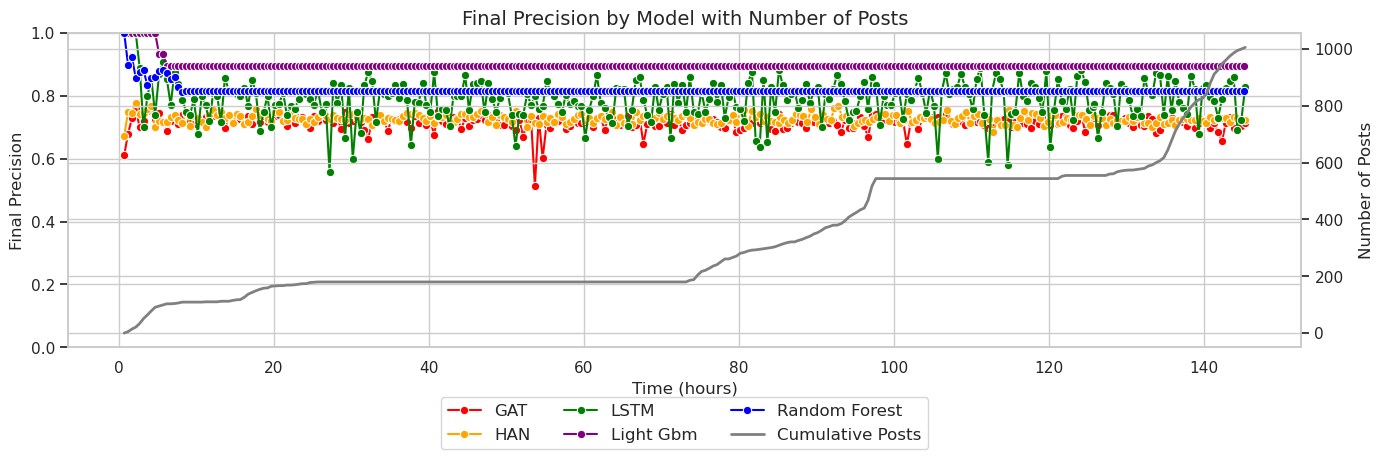

In [31]:
# Filter only even time_cuts (optional)
#df_all = df_all[df_all['metrics.time_cut'] % 4 == 0]

# Custom color palette matching Plotly
custom_palette = ['red', 'orange', 'green', 'purple', 'blue', 'brown']
unique_models = df_all['model'].unique()
palette_dict = {model: custom_palette[i % len(custom_palette)] for i, model in enumerate(unique_models)}

# Prepare figure
plt.figure(figsize=(14, 5))
sns.set(style="whitegrid")

# Left axis: precision
ax1 = sns.lineplot(
    data=df_all,
    x="time_cut_hours",
    y="metrics.final_precision",
    hue="model",
    marker="o",
    palette=palette_dict
)

# Labels for left axis
ax1.set_xlabel("Time (hours)", fontsize=12)
ax1.set_ylabel("Final Precision", fontsize=12)
ax1.set_ylim(0, 1)

# Build second axis for cumulative posts
ax2 = ax1.twinx()

# Add only GAT rumours line
df_gat = df_all[df_all["model"] == "GAT"]

sns.lineplot(
    data=df_gat,
    x="time_cut_hours",
    y="new_posts_cum_sum",
    ax=ax2,
    color="gray",
    linewidth=2,
    label="Cumulative Posts",
    palette=palette_dict
)

ax2.set_ylabel("Number of Posts", fontsize=12)

# Title
plt.title("Final Precision by Model with Number of Posts", fontsize=14)

# Fix legends: merge both axes legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Remove automatic seaborn legend from ax1
ax1.legend_.remove()

# Create combined legend
plt.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=3,
    fontsize=12
)

plt.tight_layout()
plt.show()


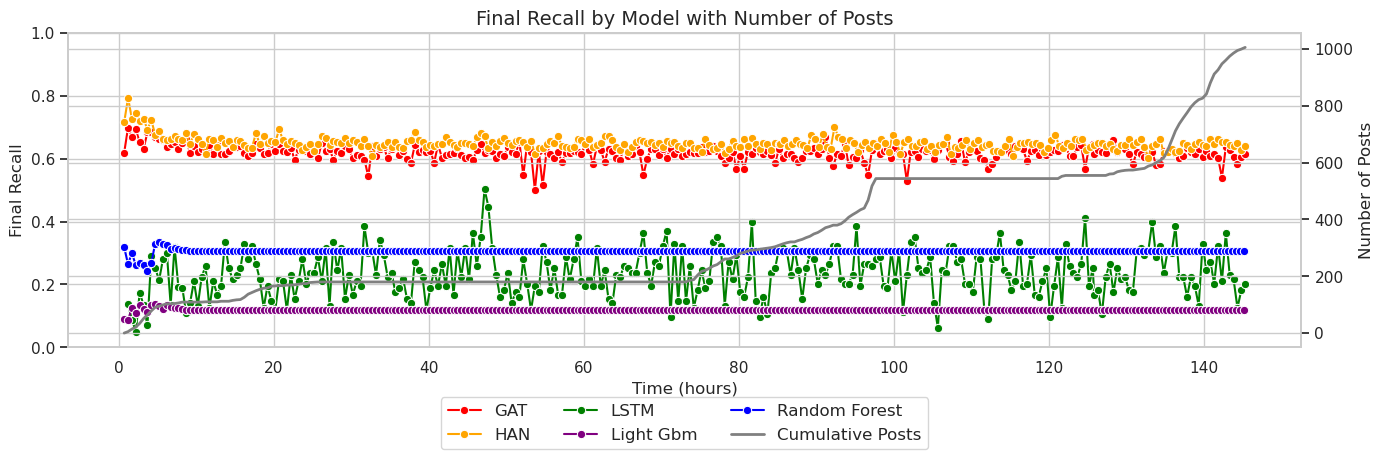

In [32]:
# Custom color palette matching Plotly
custom_palette = ['red', 'orange', 'green', 'purple', 'blue', 'brown']
unique_models = df_all['model'].unique()
palette_dict = {model: custom_palette[i % len(custom_palette)] for i, model in enumerate(unique_models)}

# Figure setup
plt.figure(figsize=(14, 5))
sns.set(style="whitegrid")

# Left axis: recall curves
ax1 = sns.lineplot(
    data=df_all,
    x="time_cut_hours",
    y="metrics.final_recall",
    hue="model",
    marker="o",
    palette=palette_dict
)

# Axis labels
ax1.set_xlabel("Time (hours)", fontsize=12)
ax1.set_ylabel("Final Recall", fontsize=12)
ax1.set_ylim(0, 1)

# Right axis: cumulative posts (GAT only)
ax2 = ax1.twinx()
df_gat = df_all[df_all["model"] == "GAT"]

sns.lineplot(
    data=df_gat,
    x="time_cut_hours",
    y="new_posts_cum_sum",
    ax=ax2,
    color="gray",
    linewidth=2,
    label="Cumulative Posts"
)

ax2.set_ylabel("Number of Posts", fontsize=12)

# Title
plt.title("Final Recall by Model with Number of Posts", fontsize=14)

# Merge legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend_.remove()  # remove default seaborn legend

plt.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=3,
    fontsize=12
)

plt.tight_layout()
plt.show()


#### Metrics at the t0 (time of post publication)
Measuring early detection

In [33]:
df_all[df_all['metrics.new_posts'] > 0] \
    .groupby('model')[['metrics.curr_recall', 'metrics.curr_precision', 'metrics.curr_f1']] \
    .agg(['mean']) \
    .round(2) \
    .sort_values(('metrics.curr_f1', 'mean'), ascending=False)


,metrics.curr_recall,metrics.curr_precision,metrics.curr_f1
,mean,mean,mean
model,,,
HAN,0.78,0.79,0.78
GAT,0.74,0.79,0.76
Random Forest,0.22,0.53,0.31
LSTM,0.19,0.50,0.26
Light Gbm,0.09,0.39,0.14


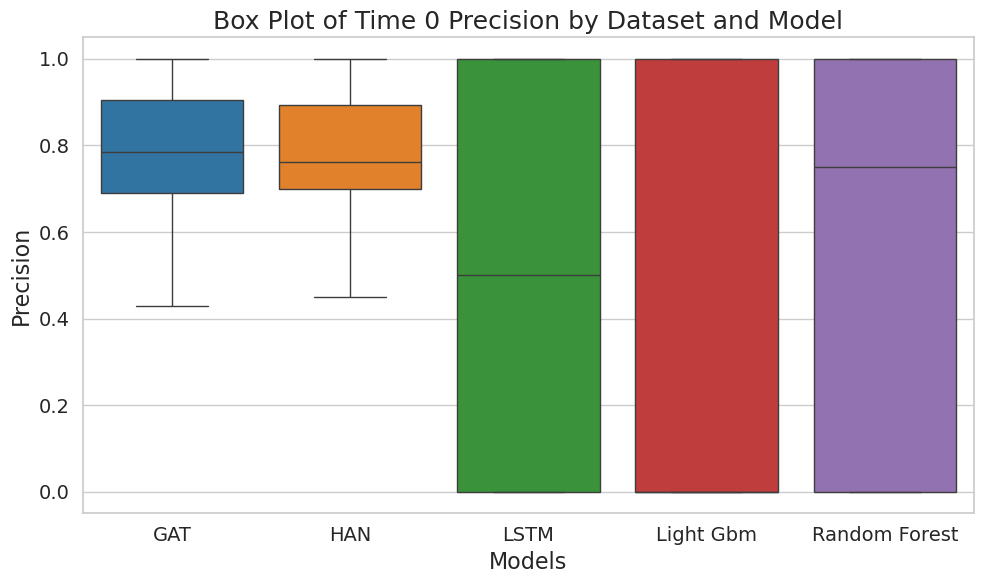

In [34]:

# Filter rows
df_plot = df_all[df_all['metrics.new_posts'] > 0]

plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Boxplot
ax = sns.boxplot(
    data=df_plot,
    x="model",
    y="metrics.curr_precision",
    hue="model",
    palette="tab10"   # or specify your own palette
)

# Labels
ax.set_title("Box Plot of Time 0 Precision by Dataset and Model", fontsize=18)
ax.set_xlabel("Models", fontsize=16)
ax.set_ylabel("Precision", fontsize=16)

# Tick size
ax.tick_params(axis='both', labelsize=14)

# Legend formatting


plt.tight_layout()
plt.show()


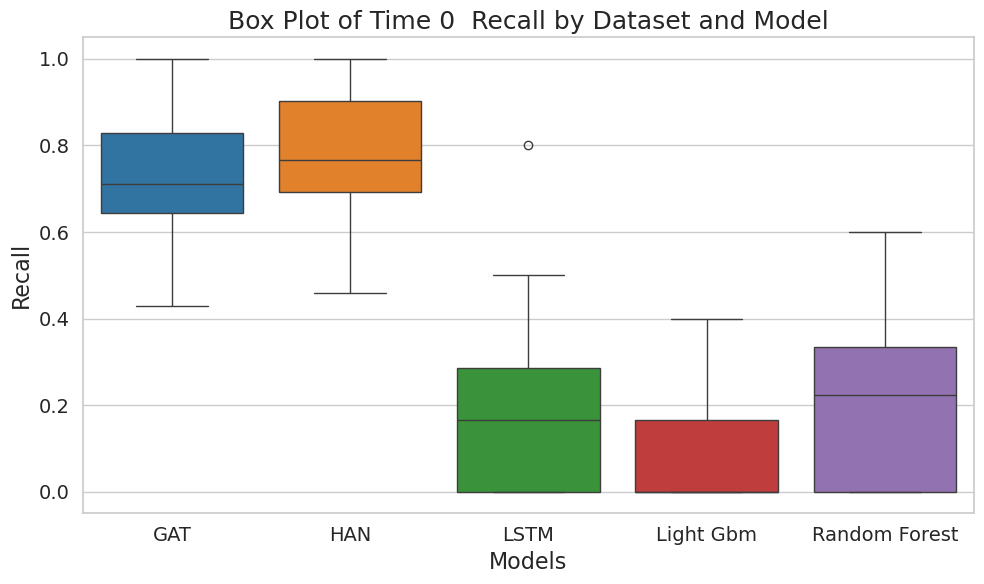

In [35]:

# Filter rows
df_plot = df_all[df_all['metrics.new_posts'] > 0]

plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Boxplot
ax = sns.boxplot(
    data=df_plot,
    x="model",
    y="metrics.curr_recall",
    hue="model",
    palette="tab10"  # can be custom if needed
)

# Labels
ax.set_title("Box Plot of Time 0  Recall by Dataset and Model", fontsize=18)
ax.set_xlabel("Models", fontsize=16)
ax.set_ylabel("Recall", fontsize=16)

# Tick size
ax.tick_params(axis='both', labelsize=14)

# Legend formatting


plt.tight_layout()
plt.show()
